# Testing the EDR and EFD Calculations

In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import pandas as pd
import numpy as np


from contigo.constellation import Constellation
from contigo.edr_efd import EDRDensity

from contigo.forces.third_body_acc import ThirdBody
from contigo.forces.grav_pot import EarthPotential
from contigo.forces.srp_acc import SRPAcc 

In [8]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")
sw_o = pd.read_hdf("./data/ore_d.hdf")

print(sw_e.columns)
print(sw_o.columns)

Index(['index', 'sat', 'x', 'y', 'z', 'DateTime', 'vx', 'vy', 'vz',
       'EstSat.EarthFixed.X', 'EstSat.EarthFixed.Y', 'EstSat.EarthFixed.Z',
       'EstSat.EarthFixed.VX', 'EstSat.EarthFixed.VY', 'EstSat.EarthFixed.VZ',
       'EstSat.TAIGregorian', 'eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy',
       'eci_vz', 'eg_x', 'eg_y', 'eg_z', 'sg_x', 'sg_y', 'sg_z', 'mg_x',
       'mg_y', 'mg_z', 'srp_x', 'srp_y', 'srp_z'],
      dtype='str')
Index(['eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy', 'eci_vz', 'eci_sn_ax',
       'eci_sn_ay', 'eci_sn_az', 'eci_mn_ax', 'eci_mn_ay', 'eci_mn_az',
       'ecef_sn_ax', 'ecef_sn_ay', 'ecef_sn_az', 'ecef_mn_ax', 'ecef_mn_ay',
       'ecef_mn_az', 'ecef_sn_px', 'ecef_sn_py', 'ecef_sn_pz', 'ecef_mn_px',
       'ecef_mn_py', 'ecef_mn_pz', 'earth_gp', 'DateTime', 'ecef_x', 'ecef_y',
       'ecef_z', 'ecef_vx,', 'ecef_vy', 'ecef_vz', 'edr', 'denom'],
      dtype='str')


In [43]:
# create a Constellation object from the ESA POD file
# and calculate thirdbody acceleration from ThirdBody
hdf_sc = Constellation(state_file=r'D:\GitHub\contigo_edr\data\ESA_pod.hdf', 
                    time_col='DateTime', x_col='x', y_col='y', z_col='z',
                    vx_col='vx', vy_col='vy', vz_col='vz', 
                    sc_id_col='filename', sc_fn_slc=slice(-11,-8),
                    tscale_input='GPS', 
                    sc_mass=4.3e+02, cr=1.8, srp_area=1, cd=3.5, drag_area=1.1)

In [22]:
hdf_sc['ESA'].cd_arr

array([3.5, 3.5, 3.5, ..., 3.5, 3.5, 3.5], shape=(138240,))

In [13]:
ep = EarthPotential()
tba = ThirdBody(body=['SUN','MOON'])
srp = SRPAcc(apistartup="api_startup_file.txt", gmat_install="C:/Users/murph/GMAT_R2025a/")

In [44]:
edr = EDRDensity(sc_system=hdf_sc,force_models=[tba,srp],potential_model=ep)

In [25]:
acc_con = edr.compute_edr()

INFO:Loading Potential coeffecients from current state which used EIGEN-2.gfc.
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
INFO:Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc
INFO:GMAT API already setup.


In [50]:
den_con = edr.compute_denom()

In [56]:
print(den_con['ESA'])
print(sw_o['denom'].to_numpy()/(1000**5))

print(np.allclose(den_con['ESA'],sw_o['denom'].to_numpy()/(1000**5)))

[0.00000000e+00 3.93727414e-05 7.87421533e-05 ... 5.42573426e+00
 5.42577318e+00 5.42581210e+00]
[0.00000000e+00 3.93727351e-05 7.87421406e-05 ... 5.42573426e+00
 5.42577318e+00 5.42581210e+00]
True


In [34]:
hdf_sc['ESA'].sc_mass_arr

array([430., 430., 430., ..., 430., 430., 430.], shape=(138240,))

In [28]:
den_con['ESA']

array([ 0., nan, nan, ..., nan, nan, nan], shape=(138240,))

In [16]:
contigo = pd.DataFrame(acc_con['ESA'])

True


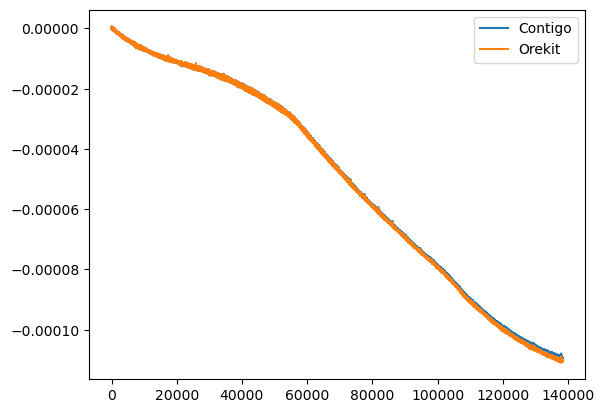

In [17]:
sw_o['edr_km'] = (sw_o['edr']-sw_o['edr'][0])/(1000**2)
ax = contigo['edr'].plot(label='Contigo')
sw_o['edr_km'].plot(ax=ax,label='Orekit')

ax.legend()

ac = np.allclose(sw_o['edr_km'].to_numpy(),contigo['edr'].to_numpy(),atol=1E-7,rtol=0.01)
print(ac)


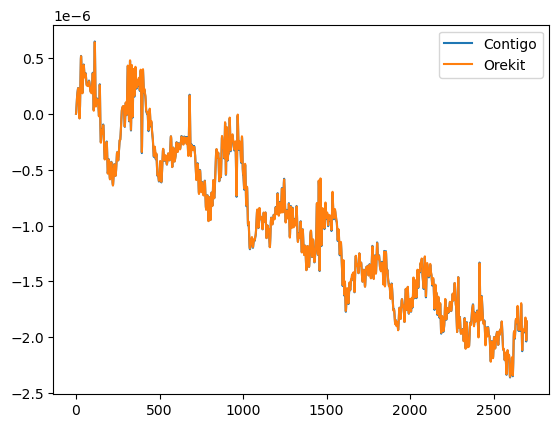

In [18]:
end = int(5*90*60/10)
ax = contigo['edr'][0:end].plot(label='Contigo')
sw_o['edr_km'][0:end].plot(ax=ax, label='Orekit')
ax.legend()
